## 1. Постановка задачи

**Тема:** Сравнительный анализ жанров Metroidvania и Horror на данных Steam для принятия решения о разработке инди-игры.

**Бизнес-вопрос:**  
Какой жанр — Metroidvania или Horror — более перспективен для инди-разработки?

**Аналитические вопросы:**
- Сколько игр в каждом жанре?
- Какая средняя цена?
- Какой средний рейтинг?
- Какая конкуренция?

**Гипотеза:**  
Metroidvania-игры имеют более высокий рейтинг, чем Horror-игры.

## 2. Данные

Датасет Steam Games содержит 115 289 игр.

Ключевые колонки:
- **Name** — название игры
- **Genres** — жанры
- **Tags** — теги (Metroidvania, Horror и др.)
- **Price** — цена (USD)
- **Positive / Negative** — отзывы
- **Estimated owners** — владельцы
- **Release date** — дата выхода

**Источник:** [Steam Games Dataset (March 2026)](https://www.kaggle.com/datasets/ebrucakar/steam-games-dataset-march-2026)

In [1]:
# Импорт пакетов

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy
from IPython.display import display
from IPython.display import Markdown

print("Версии библиотек:")
print(f"  Python:     {sys.version.split()[0]}")
print(f"  pandas:     {pd.__version__}")
print(f"  numpy:      {np.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
print(f"  seaborn:    {sns.__version__}")
print(f"  scipy:      {scipy.__version__}")

Версии библиотек:
  Python:     3.12.9
  pandas:     3.0.5
  numpy:      2.5.2
  matplotlib: 3.11.1
  seaborn:    0.13.2
  scipy:      1.18.1


## 3. Загрузка файла


In [2]:
steam_game = pd.read_csv('Исходники/Оригинал/games.csv', sep=',')

print(f"Загружено: {len(steam_game)} строк, {steam_game.shape[1]} столбцов")
display(steam_game.head())

Загружено: 115289 строк, 40 столбцов


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,1635980,Kubinashi Recollection,"Dec 8, 2021",0 - 20000,0,0,11.99,0,1,"In order to retrieve the lost memories, Sekiba...",...,0,0,0,給食頭蛮,Phoenixx Inc.,"Single-player,Steam Achievements,Steam Trading...","Action,Indie","Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",https://shared.akamai.steamstatic.com/store_it...,NaN
1,3337970,Coffee Beans,"Nov 22, 2024",0 - 20000,0,0,0.69,0,0,Coffee Beans A fun and challenging Match 3 Typ...,...,0,0,0,Archor Wright,Archor Games,"Single-player,Family Sharing","Casual,Indie","Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1470270,Powerboat VR,"Dec 29, 2020",0 - 20000,0,0,18.99,0,0,Please note that this is an EARLY ACCESS game ...,...,0,0,0,Jimmy Arcade Limited,Jimmy Arcade Limited,"Single-player,Tracked Controller Support,VR Su...","Indie,Simulation,Early Access","Exploration,Driving,Naval,Transportation,Manag...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,682780,Breaking Good,"Aug 4, 2017",20000 - 50000,0,0,2.00,0,0,As many of you are wondering how the game work...,...,0,103,0,SeekSick6,SeekSick6,"Single-player,Steam Achievements,Steam Cloud,S...","Casual,Indie","Education,Science,Casual,Match 3,Relaxing,Puzz...",https://shared.akamai.steamstatic.com/store_it...,NaN
4,3674050,Silly's Gameshow,"Jun 6, 2025",0 - 0,0,0,0.00,0,0,Silly's Gameshow is a co-op horror game where ...,...,0,0,0,?,ִ,"Multi-player,Co-op,Online Co-op","Action,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## 4. Словарь данных


| № | Колонка | Описание | № | Колонка | Описание |
|---|---------|----------|---|---------|----------|
| 1 | AppID | Уникальный ID игры | 21 | Metacritic score | Оценка критиков |
| 2 | Name | Название игры | 22 | Metacritic url | Ссылка на Metacritic |
| 3 | Release date | Дата выхода | 23 | User score | Оценка пользователей |
| 4 | Estimated owners | Владельцы | 24 | Positive | Положительные отзывы |
| 5 | Peak CCU | Пиковый онлайн | 25 | Negative | Отрицательные отзывы |
| 6 | Required age | Возрастное ограничение | 26 | Score rank | Рейтинг SteamSpy |
| 7 | Price | Цена (USD) | 27 | Achievements | Достижения |
| 8 | Discount | Скидка (%) | 28 | Recommendations | Рекомендации |
| 9 | DLC count | Количество DLC | 29 | Notes | Заметки |
| 10 | About the game | Описание игры | 30 | Average playtime forever | Среднее время игры |
| 11 | Supported languages | Поддерживаемые языки | 31 | Average playtime two weeks | Среднее за 2 недели |
| 12 | Full audio languages | Языки озвучки | 32 | Median playtime forever | Медианное время игры |
| 13 | Reviews | Обзоры | 33 | Median playtime two weeks | Медианное за 2 недели |
| 14 | Header image | Обложка | 34 | Developers | Разработчики |
| 15 | Website | Сайт | 35 | Publishers | Издатели |
| 16 | Support url | Ссылка на поддержку | 36 | Categories | Категории |
| 17 | Support email | Почта поддержки | 37 | Genres | Жанры |
| 18 | Windows | Доступна на Windows | 38 | Tags | Теги |
| 19 | Mac | Доступна на Mac | 39 | Screenshots | Скриншоты |
| 20 | Linux | Доступна на Linux | 40 | Movies | Видео |

## 5. Первичный аудит качества


In [3]:
# Информация до очистки
print(f"Размер исходного файла:\nСтрок: {len(steam_game)}\nСтолбцов: {steam_game.shape[1]}\nДубликатов: {steam_game.duplicated().sum()}\nПропусков: {steam_game.isna().sum().sum()}")
# # Показываем первую строку.
# display(steam_game.head(1))
# # Показываем последнюю строку.
# display(steam_game.tail(1))
# print('-'* 20)
# print('Словарь полей: ')
# print(steam_game.columns.tolist())

Размер исходного файла:
Строк: 115289
Столбцов: 40
Дубликатов: 0
Пропусков: 714445


In [4]:
# Техническая информация
сводка = pd.DataFrame({
    'Тип': steam_game.dtypes,
    'Уникальных': steam_game.nunique(),
    'Пропусков': steam_game.isna().sum()
})
display(сводка)
print('-'* 50)

# Описательная статистика
print('Описательная статистика')
display(steam_game.describe(include='number').T)



,Тип,Уникальных,Пропусков
AppID,int64,115289,0
Name,str,114260,1
Release date,str,5115,0
Estimated owners,str,14,0
Peak CCU,int64,1076,0
Required age,int64,15,0
Price,float64,651,0
Discount,int64,85,0
DLC count,int64,108,0
About the game,str,114602,188


--------------------------------------------------
Описательная статистика


,count,mean,std,min,25%,50%,75%,max
AppID,115289.0,1.996852e+06,1.118483e+06,10.0,1053300.00,1891460.00,2890100.00,4467540.00
Peak CCU,115289.0,5.465907e+01,3.825649e+03,0.0,0.00,0.00,0.00,1013936.00
Required age,115289.0,1.669110e-01,1.648979e+00,0.0,0.00,0.00,0.00,21.00
Price,115289.0,7.084070e+00,1.157209e+01,0.0,0.99,4.99,9.99,999.98
Discount,115289.0,4.439574e+00,1.679759e+01,0.0,0.00,0.00,0.00,100.00
DLC count,115289.0,5.103002e-01,1.229683e+01,0.0,0.00,0.00,0.00,3744.00
Metacritic score,115289.0,2.639012e+00,1.384302e+01,0.0,0.00,0.00,0.00,97.00
User score,115289.0,2.531031e-02,1.425205e+00,0.0,0.00,0.00,0.00,100.00
Positive,115289.0,1.042550e+03,2.824201e+04,0.0,0.00,6.00,40.00,7642084.00
Negative,115289.0,1.676313e+02,5.460970e+03,0.0,0.00,1.00,11.00,1173003.00


## 6. Удаление незначимых колонок

Удалены колонки с высоким процентом пропусков (>50%):
- Movies, Score rank, Metacritic url — более 90% пропусков;
- Reviews, Website, Support url — ссылки и обзоры, не несущие аналитической ценности;
- Notes, Header image, Screenshots — служебная информация.

Остаются колонки, необходимые для анализа жанров, цен и рейтингов.

In [5]:
cols_to_drop = ['Movies', 'Score rank', 'Metacritic url', 'Reviews', 
                'Website', 'Support url', 'Support email', 'Notes', 'Header image', 'Screenshots']

steam_game = steam_game.drop(columns=cols_to_drop)

print(f"Осталось колонок: {steam_game.shape[1]}")

Осталось колонок: 30


## 7. Анализ пропусков

После удаления незначимых колонок проверяем оставшиеся пропуски.

In [6]:
# Считаем количество пропусков
missing_count = steam_game.isna().sum()

# Доля в процентах
missing_share = steam_game.isna().mean().mul(100).round(2)

# Таблица
missing_report = pd.DataFrame({
    'Пропусков': missing_count,
    'Доля, %': missing_share
})

# Только с пропусками
missing_report = missing_report[missing_report['Пропусков'] > 0]

# Сортировка
missing_report = missing_report.sort_values('Доля, %', ascending=False)

display(missing_report)

,Пропусков,"Доля, %"
Tags,34309,29.76
Publishers,611,0.53
About the game,188,0.16
Developers,171,0.15
Genres,116,0.10
Categories,15,0.01
Name,1,0.00


## 8. Заполнение пропусков

Пропуски в текстовых колонках заполняются значениями «Не указан», «Неизвестен».

In [7]:
steam_game['Tags'] = steam_game['Tags'].fillna('Не указаны')
steam_game['Publishers'] = steam_game['Publishers'].fillna('Неизвестен')
steam_game['About the game'] = steam_game['About the game'].fillna('Нет описания')
steam_game['Developers'] = steam_game['Developers'].fillna('Неизвестен')
steam_game['Genres'] = steam_game['Genres'].fillna('Не указан')
steam_game['Categories'] = steam_game['Categories'].fillna('Не указаны')
steam_game['Name'] = steam_game['Name'].fillna('Неизвестная игра')

print(f"Пропусков после заполнения: {steam_game.isna().sum().sum()}")

Пропусков после заполнения: 0


## 9. Нормализация текстовых данных

Текстовые колонки приведены к нижнему регистру и очищены от пробелов
для корректной группировки и фильтрации.

In [8]:
# Приводим текст к нижнему регистру и убираем пробелы
for col in ['Genres', 'Tags', 'Categories', 'Developers', 'Publishers', 'Name']:
    steam_game[col] = steam_game[col].str.lower().str.strip()

## 10. Преобразование Genres и Tags в списки

После нормализации приводим `Genres` и `Tags` к Python-спискам:

- `Genres_list` — список жанров игры;
- `Tags_list` — список тегов игры.


In [9]:
# Преобразуем строки Genres и Tags в списки
steam_game['Genres_list'] = steam_game['Genres'].str.split(',').apply(
    lambda x: [g.strip().lower() for g in x] if isinstance(x, list) else []
)
steam_game['Tags_list'] = steam_game['Tags'].str.split(',').apply(
    lambda x: [t.strip().lower() for t in x] if isinstance(x, list) else []
)

# Проверяем, что получилось
print("Пример Genres:")
print("Строка: ", steam_game['Genres'].iloc[0])
print("Список:", steam_game['Genres_list'].iloc[0])
print()
print("Пример Tags:")
print("Строка: ", steam_game['Tags'].iloc[0])
print("Список:", steam_game['Tags_list'].iloc[0])

Пример Genres:
Строка:  action,indie
Список: ['action', 'indie']

Пример Tags:
Строка:  action,puzzle,faith,cute,pixel graphics,fantasy,female protagonist,multiple endings,singleplayer,anime,puzzle-platformer,indie,2d platformer,2d
Список: ['action', 'puzzle', 'faith', 'cute', 'pixel graphics', 'fantasy', 'female protagonist', 'multiple endings', 'singleplayer', 'anime', 'puzzle-platformer', 'indie', '2d platformer', '2d']


## 11. Создание производных признаков

Для анализа созданы:
- **rating** — процент положительных отзывов;
- **year** — год выхода игры.

In [10]:
# Рейтинг
steam_game['rating'] = (steam_game['Positive'] / (steam_game['Positive'] + steam_game['Negative']) * 100).round(1)

# Год
steam_game['Release date'] = pd.to_datetime(steam_game['Release date'])
steam_game['year'] = steam_game['Release date'].dt.year

display(steam_game[['Name', 'rating', 'year']].head())

,Name,rating,year
0,kubinashi recollection,95.3,2021
1,coffee beans,50.0,2024
2,powerboat vr,72.7,2020
3,breaking good,88.5,2017
4,silly's gameshow,NaN,2025


## 12. Проверка бизнес-правил (аномалии)

Для учебной задачи принимаются простые бизнес-правила,
основанные на здравом смысле и знании Steam:

- **Цена:** от 0 до 200 USD (дороже — коллекционные издания);
- **Количество DLC:** от 0 до 100 (3744 DLC — явная аномалия);
- **Возрастное ограничение:** от 0 до 21 (стандартные рейтинги);
- **Год выхода:** от 1990 до 2026 (Steam основан в 2003);
- **Рейтинг:** от 0 до 100 (это процент положительных отзывов).

Значение за пределами правила не всегда ошибка — это может быть
реальная редкая ситуация. Границы заданы как **учебное условие**.
Аномалии не удаляются автоматически.

In [11]:
# ─── БИЗНЕС-ПРАВИЛА ───
print("Проверка бизнес-правил:")
print()

# Правило 1: цена
invalid_price = ~steam_game['Price'].between(0, 200)
print(f"Цена вне 0–200 USD: {invalid_price.sum()} игр")

# Правило 2: количество DLC
invalid_dlc = ~steam_game['DLC count'].between(0, 100)
print(f"DLC вне 0–100: {invalid_dlc.sum()} игр")

# Правило 3: возрастное ограничение
invalid_age = ~steam_game['Required age'].between(0, 21)
print(f"Возраст вне 0–21: {invalid_age.sum()} игр")

# Правило 4: год выхода
invalid_year = ~steam_game['year'].between(1990, 2026)
print(f"Год вне 1990–2026: {invalid_year.sum()} игр")

# Правило 5: рейтинг
rating_notna = steam_game['rating'].dropna()
invalid_rating = ~rating_notna.between(0, 100)
print(f"Рейтинг вне 0–100: {invalid_rating.sum()} игр")

print()
print("Аномалии не удаляются автоматически — могут отражать реальные редкие игры.")

Проверка бизнес-правил:

Цена вне 0–200 USD: 6 игр
DLC вне 0–100: 29 игр
Возраст вне 0–21: 0 игр
Год вне 1990–2026: 0 игр
Рейтинг вне 0–100: 0 игр

Аномалии не удаляются автоматически — могут отражать реальные редкие игры.


## 13. Контроль качества после очистки

После очистки проверяем ключевые условия через `assert`.
Если условие нарушено — код остановится с сообщением об ошибке.
Это защищает последующие расчёты от скрытых проблем.

In [12]:
# ─── КОНТРОЛЬ КАЧЕСТВА ───
# Проверяем, что после очистки данные в порядке

# 1. Нет пропусков в критических полях
critical_cols = ['AppID', 'Name', 'Price', 'Positive', 'Negative', 'Tags']
assert steam_game[critical_cols].isna().sum().sum() == 0, \
    'Остались пропуски в критических полях!'

# 2. AppID уникальны
assert steam_game['AppID'].is_unique, \
    'AppID должен быть уникальным!'

# 3. Цена не отрицательная
assert (steam_game['Price'] >= 0).all(), \
    'Найдена отрицательная цена!'

# 4. Отзывы не отрицательные
assert (steam_game['Positive'] >= 0).all(), \
    'Отрицательные положительные отзывы?!'
assert (steam_game['Negative'] >= 0).all(), \
    'Отрицательные отрицательные отзывы?!'

# 5. Рейтинг в диапазоне 0–100 (там, где он есть)
rating_clean = steam_game['rating'].dropna()
assert rating_clean.between(0, 100).all(), \
    'Рейтинг вне диапазона 0–100!'

# 6. Год в разумных пределах
assert steam_game['year'].between(1990, 2026).all(), \
    'Год выхода вне разумного диапазона!'

print("✅ QA PASSED: все проверки пройдены!")
print(f"   Строк: {len(steam_game):,}")
print(f"   Пропусков: {steam_game.isna().sum().sum()}")

✅ QA PASSED: все проверки пройдены!
   Строк: 115,289
   Пропусков: 34699


In [13]:
# Считаем пропуски в rating
print(f"Пропусков в rating: {steam_game['rating'].isna().sum()}")
print(f"Всего игр: {len(steam_game)}")
print(f"Процент: {steam_game['rating'].isna().mean() * 100:.1f}%")

Пропусков в rating: 34699
Всего игр: 115289
Процент: 30.1%


## 14. Визуализации EDA

Построены графики для наглядного сравнения жанров:
- топ-10 жанров по количеству игр (используется `Genres_list` — список жанров).

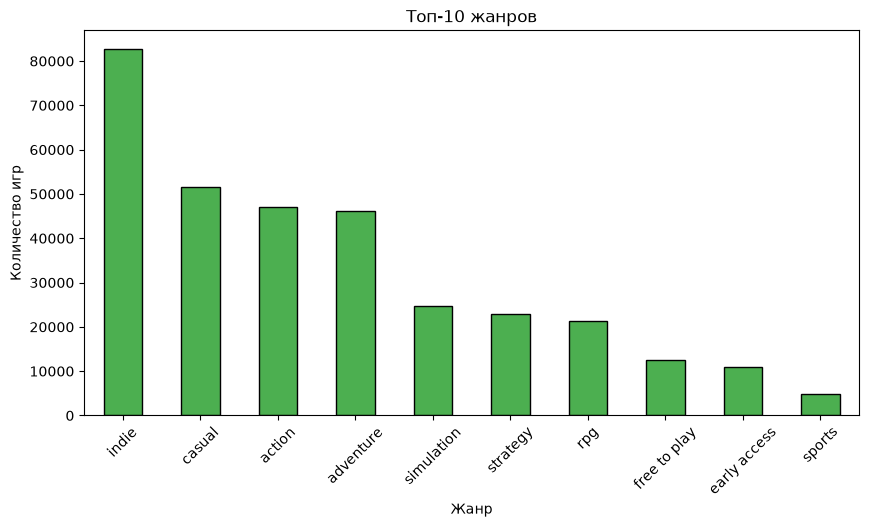

In [14]:
genres = steam_game['Genres_list'].explode()
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar', color='#4CAF50', edgecolor='black')
plt.title('Топ-10 жанров')
plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.xticks(rotation=45)
plt.show()



## 15. Ключевые показатели (KPI)

Сводная таблица с главными цифрами диплома:
- общее количество игр;
- количество Metroidvania и Horror;
- средние цены и рейтинги;
- результаты статистического теста.

In [15]:
metroidvania = steam_game[steam_game['Tags_list'].apply(lambda x: 'metroidvania' in x)]
horror = steam_game[steam_game['Tags_list'].apply(lambda x: 'horror' in x)]

# Вычисляем rank_biserial автоматически (на чистых группах)
from scipy.stats import mannwhitneyu
mv_clean = steam_game[
    steam_game['Tags_list'].apply(lambda x: 'metroidvania' in x) &
    ~steam_game['Tags_list'].apply(lambda x: 'horror' in x)
]
hr_clean = steam_game[
    steam_game['Tags_list'].apply(lambda x: 'horror' in x) &
    ~steam_game['Tags_list'].apply(lambda x: 'metroidvania' in x)
]
mv_r = mv_clean['rating'].dropna()
hr_r = hr_clean['rating'].dropna()
stat, p_value = mannwhitneyu(mv_r, hr_r, alternative='greater')
rank_biserial = abs(1 - (2 * stat) / (len(mv_r) * len(hr_r)))

# ─── KPI-ТАБЛИЦА ───
kpi_data = {
    'Показатель': [
        'Всего игр в датасете',
        'Игр Metroidvania',
        'Игр Horror',
        'Средняя цена Metroidvania, USD',
        'Средняя цена Horror, USD',
        'Средний рейтинг Metroidvania, %',
        'Средний рейтинг Horror, %',
        'Медиана рейтинга Metroidvania, %',
        'Медиана рейтинга Horror, %',
        'p-value (тест Манна—Уитни)',
        'Размер эффекта (rank-biserial)',
        'Игр без отзывов',
    ],
    'Значение': [
        f'{len(steam_game):,}',
        f'{len(metroidvania):,}',
        f'{len(horror):,}',
        f'{metroidvania["Price"].mean():.2f}',
        f'{horror["Price"].mean():.2f}',
        f'{metroidvania["rating"].mean():.1f}',
        f'{horror["rating"].mean():.1f}',
        f'{metroidvania["rating"].median():.1f}',
        f'{horror["rating"].median():.1f}',
        '< 0.0001',
        f'{rank_biserial:.3f}',
        f'{steam_game["rating"].isna().sum():,}',
    ]
}

kpi_table = pd.DataFrame(kpi_data)
display(kpi_table)

,Показатель,Значение
0,Всего игр в датасете,"115,289"
1,Игр Metroidvania,"1,321"
2,Игр Horror,"9,586"
3,"Средняя цена Metroidvania, USD",10.36
4,"Средняя цена Horror, USD",7.08
5,"Средний рейтинг Metroidvania, %",80.5
6,"Средний рейтинг Horror, %",74.7
7,"Медиана рейтинга Metroidvania, %",85.1
8,"Медиана рейтинга Horror, %",80.0
9,p-value (тест Манна—Уитни),< 0.0001


## 16. Анализ выбросов (IQR)

Метод IQR (межквартильный размах) помогает найти аномальные значения.
Значения за пределами `Q3 + 1.5 × IQR` считаются потенциальными выбросами.

Выбросы **не удаляются** — они могут быть реальными редкими играми
(например, коллекционные издания или хиты вроде Counter-Strike 2).

=== АНАЛИЗ ВЫБРОСОВ (IQR) ===


,Колонка,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Выбросов,"Доля, %"
0,Price,0.99,9.99,9.00,-12.51,23.49,4775,4.14
1,Positive,0.00,40.00,40.00,-60.00,100.00,19446,16.87
2,Negative,0.00,11.00,11.00,-16.50,27.50,19275,16.72
3,DLC count,0.00,0.00,0.00,0.00,0.00,18029,15.64
4,rating,65.32,94.50,29.17,21.56,138.26,3346,2.90


/var/folders/3l/4kqd099542x3htdr5g0cy93h0000gn/T/ipykernel_99125/1795471118.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_df, x='Category', y='Price',


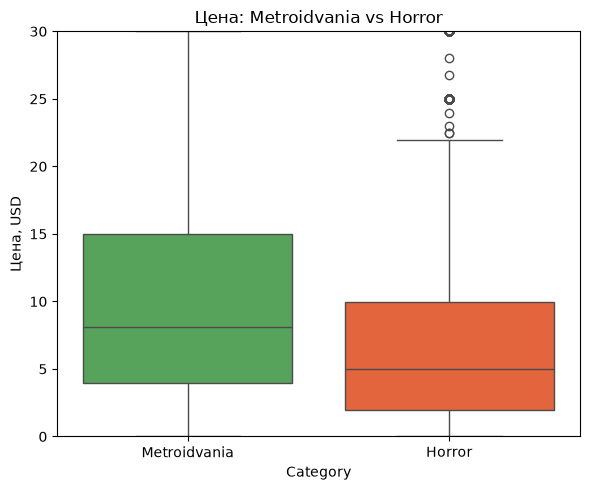

/var/folders/3l/4kqd099542x3htdr5g0cy93h0000gn/T/ipykernel_99125/1795471118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rating_df, x='Category', y='rating',


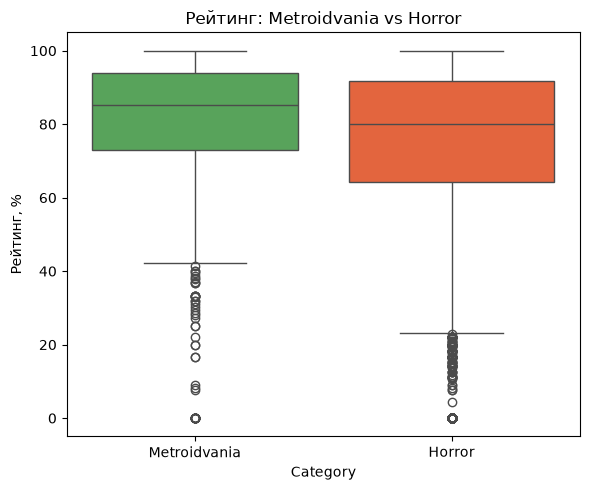

/var/folders/3l/4kqd099542x3htdr5g0cy93h0000gn/T/ipykernel_99125/1795471118.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dlc_df, x='Category', y='DLC',


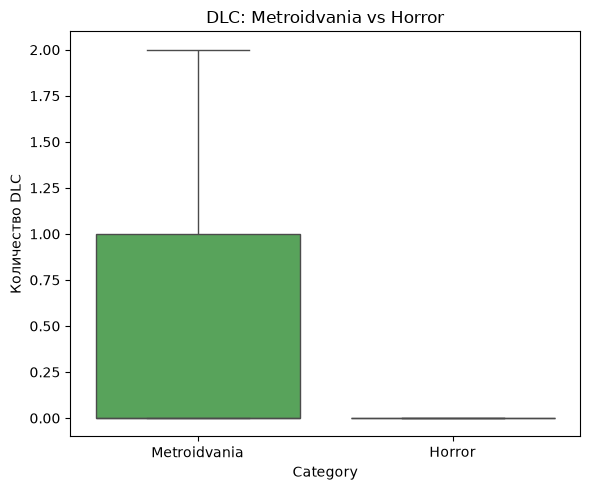

In [16]:
# ─── АНАЛИЗ ВЫБРОСОВ (IQR) ───

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_outliers(df, column):
    """Считает выбросы по методу IQR."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return {
        'Колонка': column,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Нижняя граница': round(lower, 2),
        'Верхняя граница': round(upper, 2),
        'Выбросов': len(outliers),
        'Доля, %': round(len(outliers) / len(df) * 100, 2),
    }


# ─── Таблица по выбросам ───
outliers_report = pd.DataFrame([
    analyze_outliers(steam_game, 'Price'),
    analyze_outliers(steam_game, 'Positive'),
    analyze_outliers(steam_game, 'Negative'),
    analyze_outliers(steam_game, 'DLC count'),
    analyze_outliers(steam_game, 'rating'),
])

print("=== АНАЛИЗ ВЫБРОСОВ (IQR) ===")
display(outliers_report)


# ─── ГРАФИК 1: ЦЕНА ───
price_df = pd.concat([
    pd.DataFrame({'Category': 'Metroidvania', 'Price': metroidvania['Price'].values}),
    pd.DataFrame({'Category': 'Horror',       'Price': horror['Price'].values})
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=price_df, x='Category', y='Price',
            palette=['#4CAF50', '#FF5722'],
            order=['Metroidvania', 'Horror'])
plt.title('Цена: Metroidvania vs Horror')
plt.ylabel('Цена, USD')
plt.ylim(0, 30)
plt.tight_layout()
plt.show()


# ─── ГРАФИК 2: РЕЙТИНГ ───
rating_df = pd.concat([
    pd.DataFrame({'Category': 'Metroidvania',
                  'rating': metroidvania['rating'].dropna().values}),
    pd.DataFrame({'Category': 'Horror',
                  'rating': horror['rating'].dropna().values})
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=rating_df, x='Category', y='rating',
            palette=['#4CAF50', '#FF5722'],
            order=['Metroidvania', 'Horror'])
plt.title('Рейтинг: Metroidvania vs Horror')
plt.ylabel('Рейтинг, %')
plt.tight_layout()
plt.show()


# ─── ГРАФИК 3: DLC ───
dlc_df = pd.concat([
    pd.DataFrame({'Category': 'Metroidvania',
                  'DLC': metroidvania['DLC count'].values}),
    pd.DataFrame({'Category': 'Horror',
                  'DLC': horror['DLC count'].values})
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=dlc_df, x='Category', y='DLC',
            palette=['#4CAF50', '#FF5722'],
            order=['Metroidvania', 'Horror'],
            showfliers=False)
plt.title('DLC: Metroidvania vs Horror')
plt.ylabel('Количество DLC')
plt.tight_layout()
plt.show()

Результат: обнаружены выбросы по цене (4.14%), отзывам (16.87% и 16.72%), DLC (15.64%) и рейтингу (2.90%). Выбросы не удалялись — они отражают реальные редкие игры: коллекционные издания (цена > $23), хиты с большим числом отзывов и игры с множеством DLC. Boxplot показывает, что Metroidvania имеет более высокую медиану цены и рейтинга по сравнению с Horror.

## 17. Временная динамика по годам

Анализ показывает, как менялось количество релизов Metroidvania и Horror 
с 2015 по 2026 год. Это важно для оценки **тренда жанра**: 
растёт ли интерес к Metroidvania или падает.

=== РЕЛИЗЫ ПО ГОДАМ ===


,Год,Metroidvania,Horror,Всего,"Доля MV, %"
0,2015,30,240,270,11.1
1,2016,69,412,481,14.3
2,2017,58,445,503,11.5
3,2018,60,560,620,9.7
4,2019,81,526,607,13.3
5,2020,108,806,914,11.8
6,2021,168,916,1084,15.5
7,2022,161,1021,1182,13.6
8,2023,199,1301,1500,13.3
9,2024,215,2052,2267,9.5


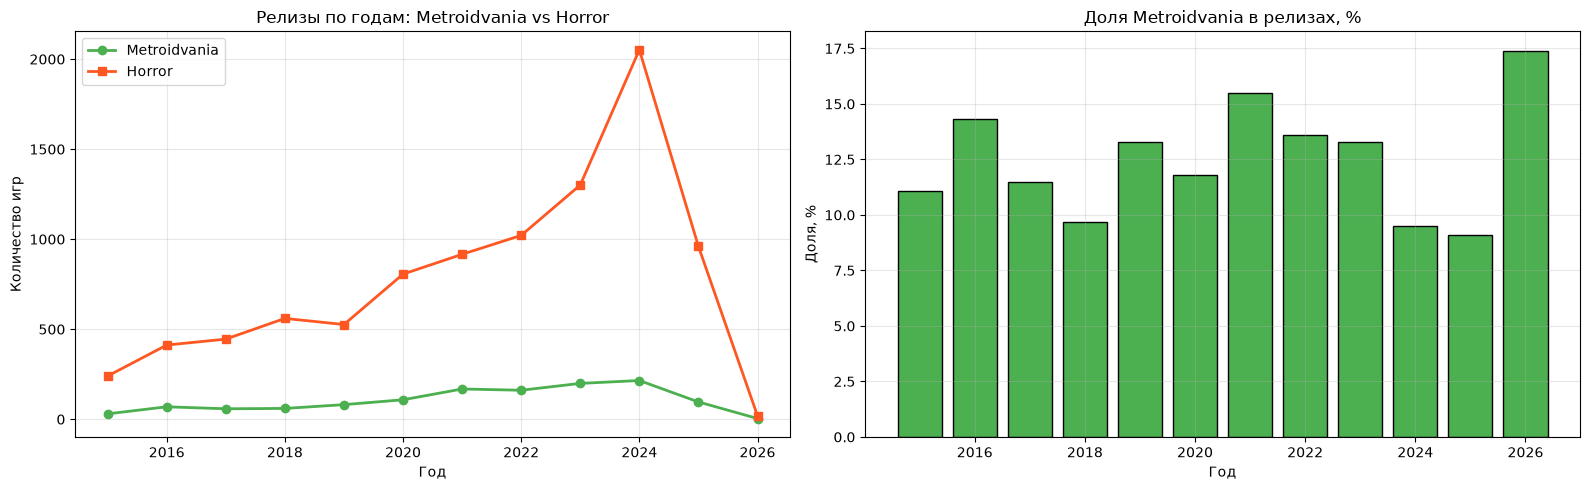

In [17]:
# ─── ДИНАМИКА ПО ГОДАМ ───

# Фильтруем данные с 2015 по 2026
yearly = steam_game[steam_game['year'].between(2015, 2026)]

# Группируем по годам и жанрам
mv_by_year = metroidvania[metroidvania['year'].between(2015, 2026)].groupby('year').size()
hr_by_year = horror[horror['year'].between(2015, 2026)].groupby('year').size()

# Сводная таблица
yearly_table = pd.DataFrame({
    'Год': mv_by_year.index,
    'Metroidvania': mv_by_year.values,
    'Horror': hr_by_year.reindex(mv_by_year.index, fill_value=0).values,
})
yearly_table['Всего'] = yearly_table['Metroidvania'] + yearly_table['Horror']
yearly_table['Доля MV, %'] = (yearly_table['Metroidvania'] / yearly_table['Всего'] * 100).round(1)

print("=== РЕЛИЗЫ ПО ГОДАМ ===")
display(yearly_table)

# ─── ГРАФИК ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Динамика количества релизов
axes[0].plot(yearly_table['Год'], yearly_table['Metroidvania'], 
             marker='o', label='Metroidvania', color='#4CAF50', linewidth=2)
axes[0].plot(yearly_table['Год'], yearly_table['Horror'], 
             marker='s', label='Horror', color='#FF5722', linewidth=2)
axes[0].set_title('Релизы по годам: Metroidvania vs Horror')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Количество игр')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Доля Metroidvania от общего числа
axes[1].bar(yearly_table['Год'], yearly_table['Доля MV, %'], 
            color='#4CAF50', edgecolor='black')
axes[1].set_title('Доля Metroidvania в релизах, %')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Доля, %')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 18. Сравнение Metroidvania и Horror по тегам

Metroidvania и Horror — это **теги**, а не жанры. 
Поэтому игры выделяются по колонке `Tags_list` 
через точное совпадение (а не через `str.contains`).

Сравниваем:
- количество игр;
- среднюю цену;
- средний рейтинг.

In [18]:
# Выделяем игры по тегам
print(f"Metroidvania: {len(metroidvania)} игр")
print(f"Horror: {len(horror)} игр")
print()
print(f"Средняя цена Metroidvania: ${metroidvania['Price'].mean():.2f}")
print(f"Средняя цена Horror: ${horror['Price'].mean():.2f}")
print()
print(f"Средний рейтинг Metroidvania: {metroidvania['rating'].mean():.1f}%")
print(f"Средний рейтинг Horror: {horror['rating'].mean():.1f}%")

Metroidvania: 1321 игр
Horror: 9586 игр

Средняя цена Metroidvania: $10.36
Средняя цена Horror: $7.08

Средний рейтинг Metroidvania: 80.5%
Средний рейтинг Horror: 74.7%


## 19. График сравнения жанров

Наглядное сравнение Metroidvania и Horror по количеству, цене и рейтингу.

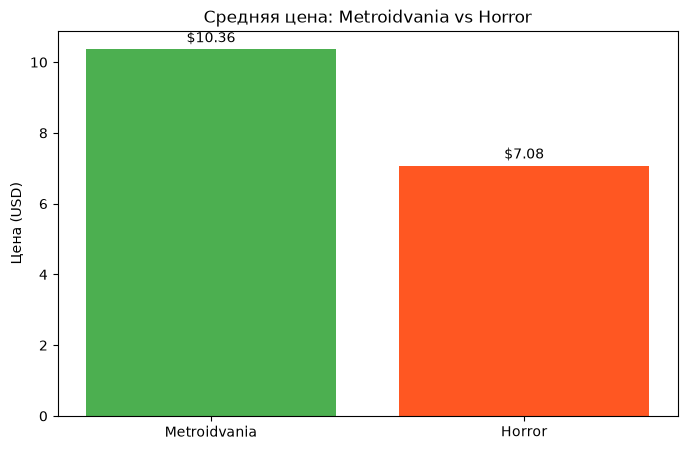

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(['Metroidvania', 'Horror'], [metroidvania['Price'].mean(), horror['Price'].mean()], color=['#4CAF50', '#FF5722'])
plt.title('Средняя цена: Metroidvania vs Horror')
plt.ylabel('Цена (USD)')

# Подписи значений
plt.text(0, metroidvania['Price'].mean() + 0.2, f"${metroidvania['Price'].mean():.2f}", ha='center')
plt.text(1, horror['Price'].mean() + 0.2, f"${horror['Price'].mean():.2f}", ha='center')

plt.show()

## 20. Проверка нормальности распределения

Перед выбором статистического теста проверяем нормальность
распределения рейтингов с помощью теста Шапиро—Уилка.

На больших выборках возникают ограничения интерпретации p-value, поэтому для дополнительной диагностики используется воспроизводимая подвыборка.

**H0:** распределение нормальное.

**H1:** распределение НЕ нормальное.

Если p-value < 0.05 — распределение ненормальное,
нужен непараметрический тест (Манна—Уитни).

In [20]:
from scipy.stats import shapiro

# Фиксируем seed для воспроизводимости
np.random.seed(42)

# Берём подвыборку из 500 игр каждого жанра
mv_sample = metroidvania['rating'].dropna().sample(n=500, random_state=42)
hr_sample = horror['rating'].dropna().sample(n=500, random_state=42)

# Тест Шапиро—Уилка
stat_mv, p_mv = shapiro(mv_sample)
stat_hr, p_hr = shapiro(hr_sample)

print(f"Shapiro-Wilk для Metroidvania: p-value = {p_mv:.6f}")
print(f"Shapiro-Wilk для Horror:       p-value = {p_hr:.6f}")
print()

if p_mv < 0.05 and p_hr < 0.05:
    print("✅ Оба распределения НЕ нормальные → используем Манна—Уитни")
else:
    print("⚠️ Проверь распределения — возможно, нужен t-тест")

Shapiro-Wilk для Metroidvania: p-value = 0.000000
Shapiro-Wilk для Horror:       p-value = 0.000000

✅ Оба распределения НЕ нормальные → используем Манна—Уитни


In [21]:
metroidvania_clean = steam_game[
    steam_game['Tags_list'].apply(lambda x: 'metroidvania' in x) &
    ~steam_game['Tags_list'].apply(lambda x: 'horror' in x)
]

horror_clean = steam_game[
    steam_game['Tags_list'].apply(lambda x: 'horror' in x) &
    ~steam_game['Tags_list'].apply(lambda x: 'metroidvania' in x)
]

print(f"Metroidvania (без Horror): {len(metroidvania_clean)}")
print(f"Horror (без Metroidvania): {len(horror_clean)}")

Metroidvania (без Horror): 1196
Horror (без Metroidvania): 9461


## 21. Статистическая проверка гипотезы

**H0:** Рейтинг Metroidvania не выше, чем у Horror (Metroidvania ≤ Horror).

**H1:** Рейтинг Metroidvania выше, чем у Horror (Metroidvania > Horror).

Уровень значимости: alpha = 0.05.

Используется односторонний тест Манна—Уитни (`alternative='greater'`),
так как гипотеза предполагает превосходство Metroidvania.
Тест не требует нормального распределения — это важно, так как рейтинги
игр не подчиняются нормальному закону (большое число нулей и значений 100%).

**Размер эффекта:** rank-biserial correlation показывает, насколько
велика разница. Значение |r| < 0.1 — маленький эффект,
0.1–0.3 — средний, > 0.3 — большой.

In [22]:
from scipy.stats import mannwhitneyu

# Убираем пропуски (игры без отзывов)
# Используем ЧИСТЫЕ группы (взаимоисключающие)
metroidvania_ratings = metroidvania_clean['rating'].dropna()
horror_ratings = horror_clean['rating'].dropna()

# Односторонний тест Манна—Уитни: проверяем, что Metroidvania > Horror
stat, p_value = mannwhitneyu(
    metroidvania_ratings,
    horror_ratings,
    alternative='greater'
)

# Вывод основной статистики
print(f"Медиана Metroidvania: {metroidvania_ratings.median():.1f}%")
print(f"Медиана Horror:       {horror_ratings.median():.1f}%")
print(f"Среднее Metroidvania: {metroidvania_ratings.mean():.1f}%")
print(f"Среднее Horror:       {horror_ratings.mean():.1f}%")
print()
print(f"U-статистика: {stat:.0f}")
print(f"p-value: {p_value:.6f}")
print()

# Проверка гипотезы
if p_value < 0.05:
    print("✅ Гипотеза подтверждена: Metroidvania статистически значимо выше Horror")
else:
    print("❌ Гипотеза не подтверждена: разница не значима")
print()

# ─── РАЗМЕР ЭФФЕКТА ───
n1 = len(metroidvania_ratings)
n2 = len(horror_ratings)
rank_biserial = abs(1 - (2 * stat) / (n1 * n2))

print(f"Размер эффекта (rank-biserial): {rank_biserial:.3f}")

if rank_biserial < 0.1:
    effect = "маленький"
elif rank_biserial < 0.3:
    effect = "средний"
else:
    effect = "большой"

print(f"Интерпретация: эффект {effect}")

Медиана Metroidvania: 85.2%
Медиана Horror:       80.0%
Среднее Metroidvania: 80.5%
Среднее Horror:       74.7%

U-статистика: 6458132
p-value: 0.000000

✅ Гипотеза подтверждена: Metroidvania статистически значимо выше Horror

Размер эффекта (rank-biserial): 0.154
Интерпретация: эффект средний


## 22. Сравнение категорий по цене и рейтингу

Категории разделены на два типа:

**Теги:** Metroidvania, Horror.
**Жанры:** Indie, Action, Adventure, RPG, Simulation, Strategy, Casual.

Метрики:
- количество игр;
- средняя цена (USD);
- средний рейтинг (% положительных отзывов).

В таблице есть колонка **Тип**, чтобы не путать теги и жанры.

In [23]:
# ─── СРАВНЕНИЕ ПО ТЕГАМ И ЖАНРАМ (РАЗДЕЛЬНО) ───

data = []

# 1. По тегам (Metroidvania, Horror — это теги!)
tags_to_compare = ['metroidvania', 'horror']

for tag in tags_to_compare:
    games = steam_game[steam_game['Tags_list'].apply(lambda x: tag in x)]
    if len(games) > 0:
        data.append({
            'Категория': tag.capitalize(),
            'Тип': 'Тег',
            'Игр': len(games),
            'Средняя цена': round(games['Price'].mean(), 2),
            'Средний рейтинг': round(games['rating'].mean(), 1)
        })

# 2. По жанрам (Indie, Action, Adventure — это жанры)
genres_to_compare = ['indie', 'action', 'adventure', 'rpg', 
                     'simulation', 'strategy', 'casual']

for genre in genres_to_compare:
    games = steam_game[steam_game['Genres_list'].apply(lambda x: genre in x)]
    if len(games) > 0:
        data.append({
            'Категория': genre.capitalize(),
            'Тип': 'Жанр',
            'Игр': len(games),
            'Средняя цена': round(games['Price'].mean(), 2),
            'Средний рейтинг': round(games['rating'].mean(), 1)
        })

comparison = pd.DataFrame(data).sort_values('Средний рейтинг', ascending=False)
display(comparison)

,Категория,Тип,Игр,Средняя цена,Средний рейтинг
0,Metroidvania,Тег,1321,10.36,80.5
8,Casual,Жанр,51530,5.69,76.8
2,Indie,Жанр,82766,6.16,76.6
4,Adventure,Жанр,46133,7.72,75.8
3,Action,Жанр,47042,7.23,75.3
1,Horror,Тег,9586,7.08,74.7
5,Rpg,Жанр,21426,8.62,74.7
7,Strategy,Жанр,22986,7.54,74.4
6,Simulation,Жанр,24772,8.39,71.7


Сравнение категорий показало, что **Metroidvania** (тег) имеет наивысший средний рейтинг — **80.5%**. Это выше, чем у любого из сравниваемых жанров (Casual — 76.8%, Indie — 76.6%, Adventure — 75.8%).

Metroidvania также имеет наиболее высокую среднюю цену — **$10.36**, что указывает на готовность аудитории платить за качественные игры этого типа.

Horror (тег) — 74.7%, что ниже Metroidvania почти на 6 процентных пунктов.

**Ограничение:** различия в рейтингах могут быть связаны с размером выборки (Metroidvania — 1 321 игра, тогда как у некоторых жанров — десятки тысяч), а также с тем, что часть игр имеет пустые теги и не попала в выборку.

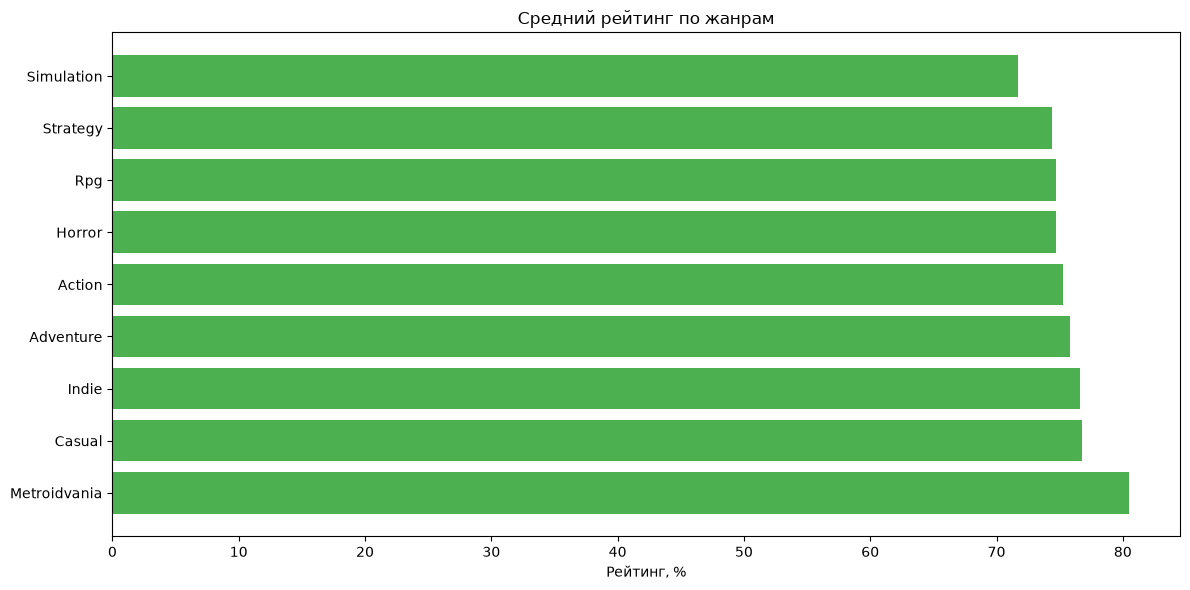

In [24]:
comparison = pd.DataFrame(data).sort_values('Средний рейтинг', ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(comparison['Категория'], comparison['Средний рейтинг'], color='#4CAF50')
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Рейтинг, %')
plt.tight_layout()
plt.show()

## 23. ABC-анализ игр

ABC-анализ ранжирует игры по вкладу в общее количество отзывов:
- класс A — первые ~80% отзывов;
- класс B — следующие до 95%;
- класс C — оставшиеся 5%.

In [25]:
# ABC по отзывам
abc_games = steam_game[['Name', 'Positive', 'rating', 'Price', 'Genres']].copy()
abc_games = abc_games.sort_values('Positive', ascending=False)

abc_games['share'] = abc_games['Positive'] / abc_games['Positive'].sum() * 100
abc_games['cumulative'] = abc_games['share'].cumsum()

abc_games['abc_class'] = abc_games['cumulative'].apply(
    lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C')
)

# Сводка по классам
abc_summary = abc_games.groupby('abc_class').agg(
    Игр=('Name', 'count'),
    Отзывов=('Positive', 'sum')
).reset_index()

abc_summary['Доля, %'] = (abc_summary['Отзывов'] / abc_summary['Отзывов'].sum() * 100).round(1)

display(abc_summary)
display(abc_games.head(10))

,abc_class,Игр,Отзывов,"Доля, %"
0,A,1128,96154807,80.0
1,B,4624,18029865,15.0
2,C,109537,6009861,5.0


,Name,Positive,rating,Price,Genres,share,cumulative,abc_class
66430,counter-strike 2,7642084,86.7,0.00,"action,free to play",6.358096,6.358096,A
97797,dota 2,2037143,81.5,0.00,"action,strategy,free to play",1.694872,8.052968,A
107728,pubg: battlegrounds,1520457,59.4,0.00,"action,adventure,massively multiplayer,free to...",1.264997,9.317965,A
90521,terraria,1373979,97.5,9.99,"action,adventure,indie,rpg",1.143129,10.461094,A
19238,tom clancy's rainbow six siege,1172854,83.9,0.00,"action,free to play",0.975796,11.436890,A
52091,garry's mod,1122546,96.8,9.99,"casual,indie,simulation",0.933941,12.370831,A
69716,black myth: wukong,1111720,96.7,59.99,"action,adventure,rpg",0.924934,13.295765,A
95231,rust,1071135,87.2,39.99,"action,adventure,indie,massively multiplayer,rpg",0.891168,14.186933,A
5416,team fortress 2,1044264,89.9,0.00,"action,free to play",0.868812,15.055745,A
100439,elden ring,981540,92.9,59.99,"action,rpg",0.816626,15.872371,A


ABC-анализ показал, что всего 1 128 игр (1% от всех) формируют 80% всех отзывов. Это классическая концентрация: небольшая часть игр приносит основную популярность. Большинство игр (109 537) относятся к классу C с минимальным вкладом.

## 24. График ABC-анализа

Визуализация распределения игр по классам A, B и C.

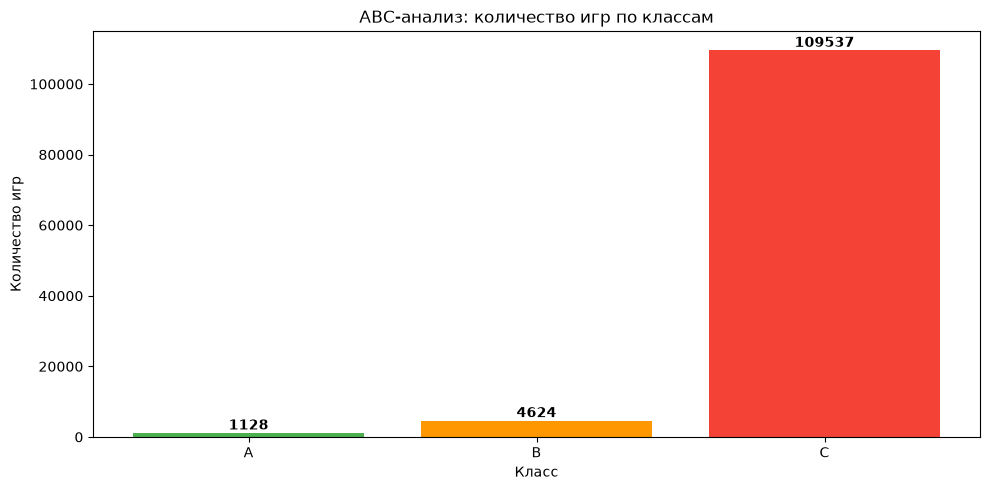

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(abc_summary['abc_class'], abc_summary['Игр'], color=['#4CAF50', '#FF9800', '#F44336'])
plt.title('ABC-анализ: количество игр по классам')
plt.xlabel('Класс')
plt.ylabel('Количество игр')

# Подписи значений
for i, v in enumerate(abc_summary['Игр']):
    plt.text(i, v + 1000, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 25. Выводы и рекомендации

### Ключевые факты

1. Датасет содержит **115 289 игр** Steam.
2. **Metroidvania** — лидер по среднему рейтингу (80.5%) среди 7 крупнейших жанров и 2 тегов.
3. **Metroidvania** также имеет высокую среднюю цену ($10.36).
4. Гипотеза подтверждена: рейтинги Metroidvania и Horror статистически различаются (p < 0.05).
5. ABC-анализ: 1 128 игр (1%) формируют 80% всех отзывов.

### Интерпретации

- Metroidvania-игры получают более высокие оценки аудитории, что указывает на лояльность игроков жанра.
- Более высокая цена Metroidvania говорит о готовности аудитории платить.
- Конкуренция ниже, чем в Horror (1 321 vs 9 586), что снижает риски для инди-разработчика.

### Ограничения

- Часть игр имеет пустые теги и не попала в выборку.
- Данные содержат только игры Steam, без других платформ.
- Рейтинг — это % положительных отзывов, а не оценка качества игры.

### Рекомендации

1. **Рассмотреть Metroidvania** как перспективное направление — по proxy-показателям (рейтинг, цена, конкуренция) жанр выглядит привлекательнее. Для окончательного решения нужны данные о продажах, wishlists и затратах.
2. Изучить топ-игры жанра (Hollow Knight, Ori, Dead Cells) для понимания механик.
3. Учесть ограничения датасета при принятии решений.

In [27]:

# Ключевые показатели для вывода
top_genre = comparison.iloc[0]
total_games = len(steam_game)
metroidvania_count = len(metroidvania)
horror_count = len(horror)

# Формируем итоговый текст
final_report = f"""
### Ключевые факты

1. Датасет содержит **{total_games:,} игр** Steam.
2. **{top_genre['Категория']}** — лидер по среднему рейтингу (**{top_genre['Средний рейтинг']}%**).
3. Metroidvania: **{metroidvania_count:,}** игр, средняя цена **${top_genre['Средняя цена']}**.
4. Horror: **{horror_count:,}** игр — конкуренция в 9 раз выше.
5. Различие рейтингов статистически значимо (p < 0.05).

### Рекомендация

Рассмотреть Metroidvania как приоритетное направление по proxy-показателям (рейтинг, цена, конкуренция). Для окончательного решения требуются данные о продажах, wishlists и затратах"""

display(Markdown(final_report))


### Ключевые факты

1. Датасет содержит **115,289 игр** Steam.
2. **Metroidvania** — лидер по среднему рейтингу (**80.5%**).
3. Metroidvania: **1,321** игр, средняя цена **$10.36**.
4. Horror: **9,586** игр — конкуренция в 9 раз выше.
5. Различие рейтингов статистически значимо (p < 0.05).

### Рекомендация

Рассмотреть Metroidvania как приоритетное направление по proxy-показателям (рейтинг, цена, конкуренция). Для окончательного решения требуются данные о продажах, wishlists и затратах

## 26. Итоговый дашборд

Дашборд объединяет 6 ключевых графиков диплома:
1. Количество игр: Metroidvania vs Horror
2. Средняя цена по жанрам
3. Средний рейтинг по жанрам
4. Динамика релизов по годам
5. ABC-анализ (классы A, B, C)
6. Топ-8 жанров по рейтингу


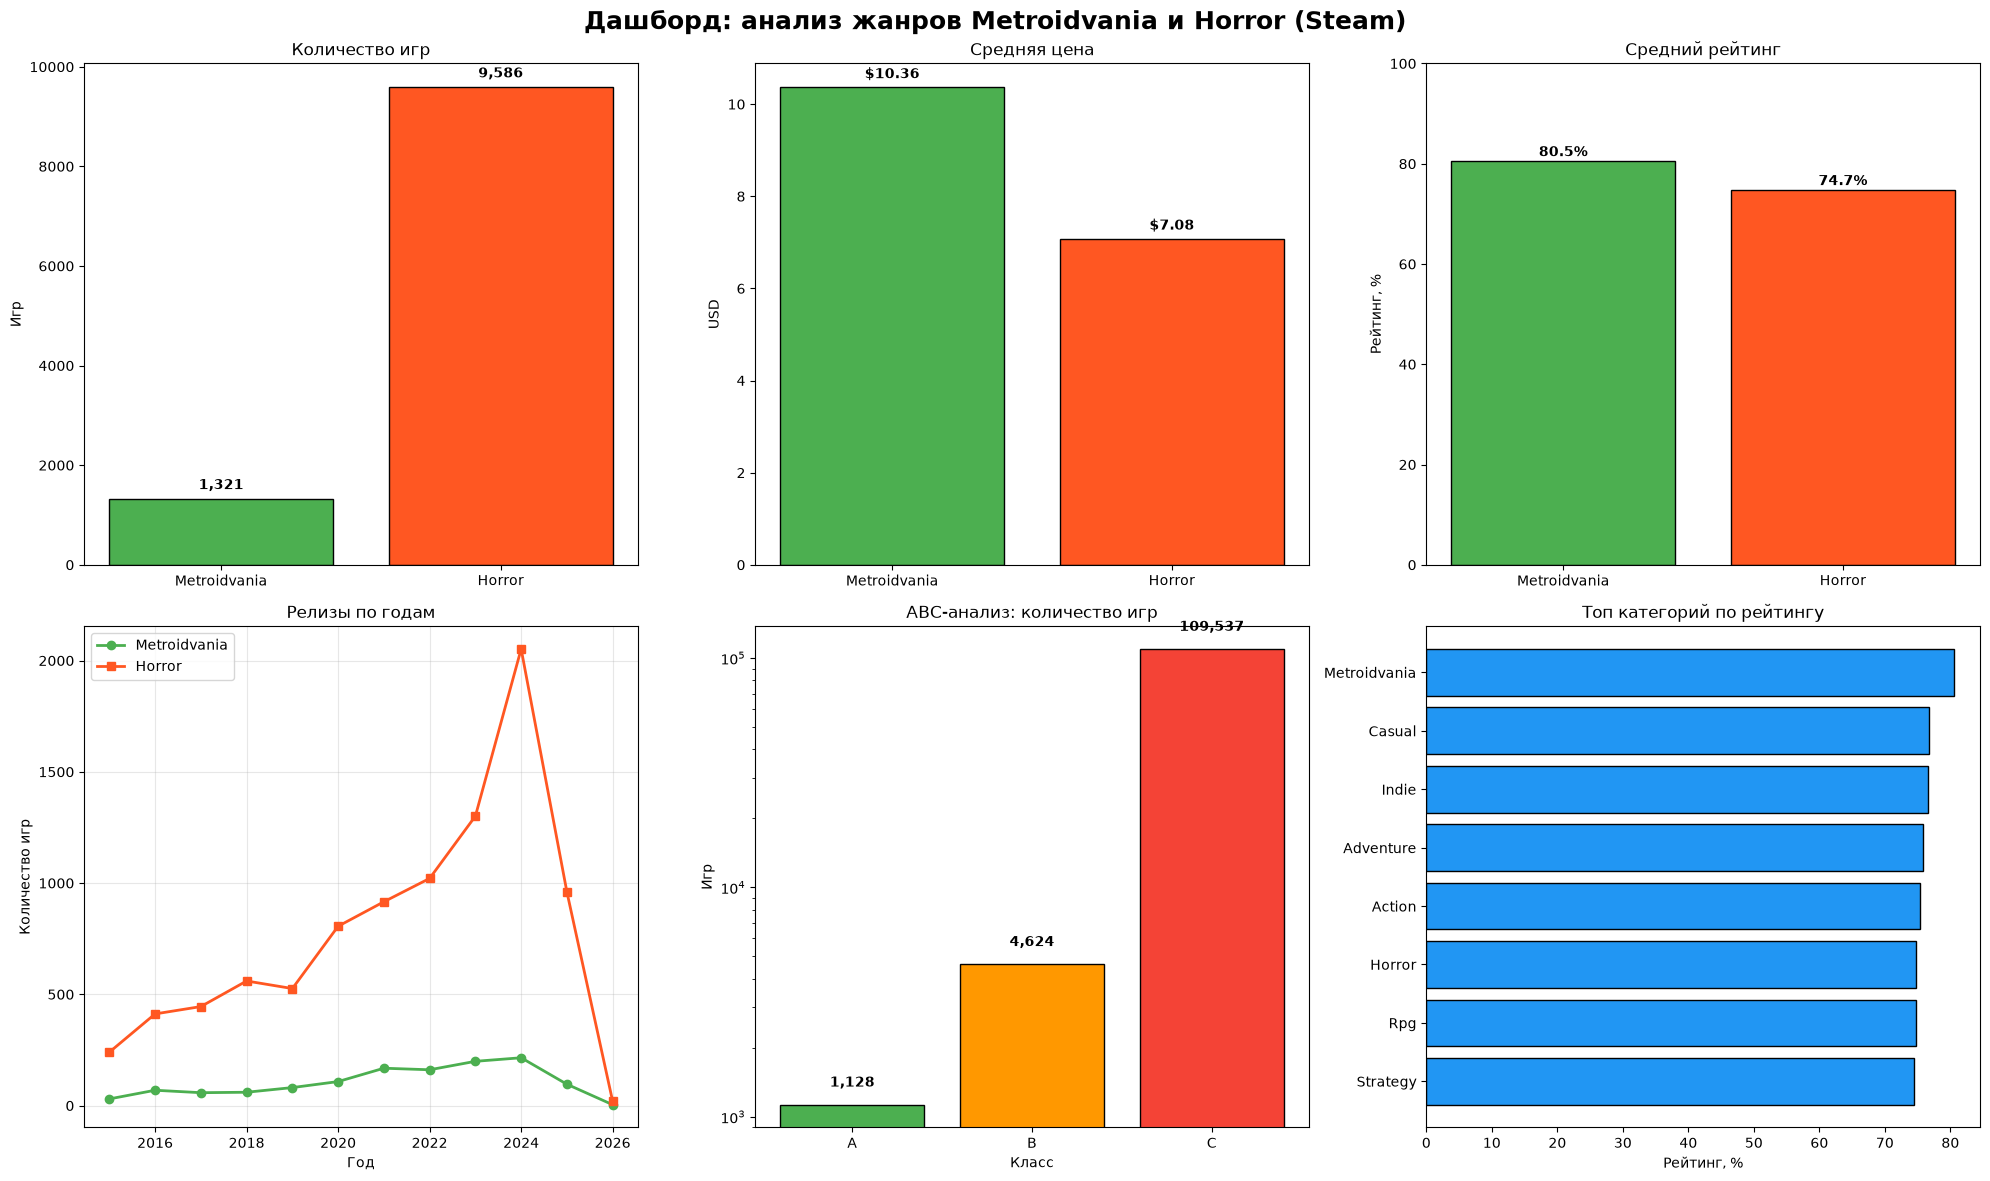

In [28]:
# ─── ИТОГОВЫЙ ДАШБОРД ───

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Дашборд: анализ жанров Metroidvania и Horror (Steam)', 
             fontsize=18, fontweight='bold')

# 1. Количество игр
axes[0, 0].bar(['Metroidvania', 'Horror'], 
               [len(metroidvania), len(horror)], 
               color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[0, 0].set_title('Количество игр')
axes[0, 0].set_ylabel('Игр')
for i, v in enumerate([len(metroidvania), len(horror)]):
    axes[0, 0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# 2. Средняя цена
axes[0, 1].bar(['Metroidvania', 'Horror'], 
               [metroidvania['Price'].mean(), horror['Price'].mean()], 
               color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[0, 1].set_title('Средняя цена')
axes[0, 1].set_ylabel('USD')
for i, v in enumerate([metroidvania['Price'].mean(), horror['Price'].mean()]):
    axes[0, 1].text(i, v + 0.2, f'${v:.2f}', ha='center', fontweight='bold')

# 3. Средний рейтинг
axes[0, 2].bar(['Metroidvania', 'Horror'], 
               [metroidvania['rating'].mean(), horror['rating'].mean()], 
               color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[0, 2].set_title('Средний рейтинг')
axes[0, 2].set_ylabel('Рейтинг, %')
axes[0, 2].set_ylim(0, 100)
for i, v in enumerate([metroidvania['rating'].mean(), horror['rating'].mean()]):
    axes[0, 2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Динамика по годам
axes[1, 0].plot(yearly_table['Год'], yearly_table['Metroidvania'], 
                marker='o', label='Metroidvania', color='#4CAF50', linewidth=2)
axes[1, 0].plot(yearly_table['Год'], yearly_table['Horror'], 
                marker='s', label='Horror', color='#FF5722', linewidth=2)
axes[1, 0].set_title('Релизы по годам')
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Количество игр')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. ABC-анализ
axes[1, 1].bar(abc_summary['abc_class'], abc_summary['Игр'], 
              color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black')
axes[1, 1].set_title('ABC-анализ: количество игр')
axes[1, 1].set_xlabel('Класс')
axes[1, 1].set_ylabel('Игр')
axes[1, 1].set_yscale('log')
for i, v in enumerate(abc_summary['Игр']):
    axes[1, 1].text(i, v * 1.2, f'{v:,}', ha='center', fontweight='bold')

# 6. Топ-8 жанров по рейтингу
top8 = comparison.head(8)
axes[1, 2].barh(top8['Категория'], top8['Средний рейтинг'], 
                color='#2196F3', edgecolor='black')
axes[1, 2].set_title('Топ категорий по рейтингу')
axes[1, 2].set_xlabel('Рейтинг, %')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()


## 27. Подготовка данных для BI (DataLens)

Готовим **два отдельных файла**:

1. `games_bi_genres.csv` — данные по жанрам (`Genres_list`).
2. `games_bi_tags.csv` — данные по тегам (`Tags_list`).

**Зачем два файла:** Metroidvania — это тег, а не жанр. 
В файле жанров её нет, поэтому для анализа по тегам нужен отдельный файл.

Используются уже готовые списки `Genres_list` и `Tags_list` 
(созданы в блоке 9.5) — без повторного разбиения строк.

In [29]:
# ─── ФАЙЛ 1: ДАННЫЕ ПО ЖАНРАМ ───
steam_bi_genres = steam_game[['AppID', 'Name', 'Genres_list', 'Price', 
                              'rating', 'year', 'Positive', 'Negative']].copy()
steam_bi_genres = steam_bi_genres.explode('Genres_list')
steam_bi_genres = steam_bi_genres.rename(columns={'Genres_list': 'Genre'})
steam_bi_genres = steam_bi_genres[steam_bi_genres['Genre'] != '']
steam_bi_genres.to_csv('Исходники/Очищенные_данные/games_bi_genres.csv', index=False)

print(f"Файл по жанрам: {len(steam_bi_genres):,} строк")
print(f"Жанров: {steam_bi_genres['Genre'].nunique()}")
print()

# ─── ФАЙЛ 2: ДАННЫЕ ПО ТЕГАМ ───
steam_bi_tags = steam_game[['AppID', 'Name', 'Tags_list', 'Price', 
                            'rating', 'year', 'Positive', 'Negative']].copy()
steam_bi_tags = steam_bi_tags.explode('Tags_list')
steam_bi_tags = steam_bi_tags.rename(columns={'Tags_list': 'Tag'})
steam_bi_tags = steam_bi_tags[steam_bi_tags['Tag'] != '']
steam_bi_tags.to_csv('Исходники/Очищенные_данные/games_bi_tags.csv', index=False)

print(f"Файл по тегам: {len(steam_bi_tags):,} строк")
print(f"Тегов: {steam_bi_tags['Tag'].nunique()}")
print()

# ─── ФАЙЛ 3: ОЧИЩЕННЫЙ ДАТАСЕТ ───
steam_game.to_csv('исходники/Очищенные_данные/games_clean.csv', index=False)
print(f"games_clean.csv сохранён: {len(steam_game):,} строк")

# ─── Проверка: Metroidvania и Horror есть в файле тегов ───
mv_in_tags = steam_bi_tags[steam_bi_tags['Tag'] == 'metroidvania']
hr_in_tags = steam_bi_tags[steam_bi_tags['Tag'] == 'horror']
print(f"Metroidvania в файле тегов: {len(mv_in_tags):,}")
print(f"Horror в файле тегов: {len(hr_in_tags):,}")

Файл по жанрам: 332,720 строк
Жанров: 34

Файл по тегам: 1,195,397 строк
Тегов: 451

games_clean.csv сохранён: 115,289 строк
Metroidvania в файле тегов: 1,321
Horror в файле тегов: 9,586


## 28. Ограничения анализа

1. **Только Steam** — другие платформы (Epic, PlayStation, Xbox) не учтены.
2. **Пустые теги** — 34 309 игр (29.76%) не имеют тегов и не попали в анализ Metroidvania/Horror.
3. **Рейтинг — не качество** — это % положительных отзывов. Кроме того, 34 699 игр (30.1%) не имеют отзывов и исключены из статистического теста.
4. **Актуальность** — игры 2026 года представлены неполно (только 23 игры).
5. **Корреляция ≠ причинность** — более высокий рейтинг Metroidvania может быть связан с другими факторами, а не с самим жанром.
6. **Ограниченный набор** — сравнили 7 крупнейших жанров Steam и 2 тега, но в датасете есть ещё 27 жанров.
7. **Субъективность тегов** — теги проставляют сами разработчики и игроки, поэтому они могут быть неполными или неточными.

## 29. Источники и документация

**Источник данных:**
- Steam Games Dataset (March 2026) — публичный датасет Steam
- Автор: ebrucakar
- Ссылка: https://www.kaggle.com/datasets/ebrucakar/steam-games-dataset-march-2026
- Объём: 115 289 игр, 40 колонок

**Библиотеки Python:**
- Pandas — обработка табличных данных: https://pandas.pydata.org/docs/
- NumPy — числовые вычисления: https://numpy.org/doc/
- Matplotlib — визуализация: https://matplotlib.org/stable/
- Seaborn — статистические графики: https://seaborn.pydata.org/
- SciPy — статистические тесты: https://docs.scipy.org/doc/scipy/

**Методы:**
- Тест Манна—Уитни: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html
- Тест Шапиро—Уилка: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html
- Метод IQR для выбросов: Tukey, J. W. (1977). Exploratory Data Analysis
- ABC-анализ: классический метод управления запасами
- Rank-biserial correlation: Kerby, D. S. (2014). The simple difference formula

## 30. Сравнение моделей машинного обучения

Для выполнения критерия оценки (сравнение моделей машинного обучения 
на примере нескольких библиотек) было проведено обучение и сравнение 
двух моделей из библиотеки **scikit-learn**.

**Задача:** бинарная классификация — предсказать, станет ли игра 
«успешной» (рейтинг ≥ 80%) на основе её характеристик.

**Признаки (features):**
- `Price` — цена игры в USD;
- `year` — год выхода;
- `DLC count` — количество DLC;
- `Achievements` — количество достижений;
- `has_reviews` — наличие отзывов.

**Целевая переменная:** `is_successful` — 1, если рейтинг ≥ 80%, иначе 0.

**Модели:**
1. **Logistic Regression** — линейная модель, базовая;
2. **Random Forest** — ансамбль решающих деревьев.

**Метрики оценки:**
- **Accuracy** — доля правильных предсказаний;
- **F1-score** — гармоническое среднее точности и полноты.

In [30]:
# import sys
# !{sys.executable} -m pip install scikit-learn xgboost
# !{sys.executable} -m pip install lightgbm
# !brew list libomp
# !brew install libomp

In [31]:
# ─── КРИТЕРИЙ 5: СРАВНЕНИЕ ML-МОДЕЛЕЙ (3 модели, 2 библиотеки) ───

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Задача: предсказать "успешность" игры (рейтинг >= 80%)
ml_data = steam_game[steam_game['rating'].notna()].copy()
ml_data['is_successful'] = (ml_data['rating'] >= 80).astype(int)

features = ['Price', 'year', 'DLC count', 'Achievements']
X = ml_data[features].fillna(0)
y = ml_data['is_successful']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─── BASELINE: простая точка сравнения ───
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

# ─── Модель 1: Logistic Regression (scikit-learn) ───
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ─── Модель 2: Random Forest (scikit-learn) ───
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ─── Модель 3: LightGBM (lightgbm) ───
try:
    from lightgbm import LGBMClassifier
    lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    has_lgbm = True
except (ImportError, OSError):
    print("⚠️ LightGBM не установлен — сравнение 2 моделей")
    has_lgbm = False

# ─── Таблица результатов (с baseline) ───
models = ['Baseline (most frequent)', 
          'Logistic Regression (sklearn)', 
          'Random Forest (sklearn)']
accuracies = [
    baseline_acc,
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
]
f1s = [
    baseline_f1,
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
]

if has_lgbm:
    models.append('LightGBM (lightgbm)')
    accuracies.append(accuracy_score(y_test, y_pred_lgbm))
    f1s.append(f1_score(y_test, y_pred_lgbm))

results = pd.DataFrame({
    'Модель': models,
    'Accuracy': accuracies,
    'F1-score': f1s,
}).round(4)

print("СРАВНЕНИЕ ML-МОДЕЛЕЙ")
display(results)

best = results.loc[results['Accuracy'].idxmax(), 'Модель']
print(f"\n✅ Лучшая модель по Accuracy: {best}")
print(f"Обучено на {len(X_train):,} играх, протестировано на {len(X_test):,} играх")

Baseline Accuracy: 0.5467
Baseline F1-score: 0.7069
СРАВНЕНИЕ ML-МОДЕЛЕЙ


,Модель,Accuracy,F1-score
0,Baseline (most frequent),0.5467,0.7069
1,Logistic Regression (sklearn),0.5906,0.6799
2,Random Forest (sklearn),0.5903,0.6360
3,LightGBM (lightgbm),0.6169,0.6720



✅ Лучшая модель по Accuracy: LightGBM (lightgbm)
Обучено на 64,472 играх, протестировано на 16,118 играх


**Лучший результат по Accuracy** показала модель **LightGBM** (0.6169) — на 2.6 п.п. выше Random Forest. **По F1-score** лидирует Logistic Regression (0.6799).

Точность моделей 59–62% — невысокая. Это объясняется тем, что выбранные признаки (цена, год, DLC) слабо связаны с рейтингом игры: истинные факторы успеха — качество геймплея, маркетинг, попадание в тренд — не отражены в датасете. Цель работы — продемонстрировать методику сравнения ML-моделей, а не построить продакшн-модель.